<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/DATASET2_Intel_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy import optimize

%matplotlib inline

# LABORATORIO 04 - GRUPO 2
## Regresión Logística One-vs-All para Clasificación Multiclase
### Dataset 2: Intel Image Classification - Natural Scenes

**Objetivo:** Clasificación multiclase de escenas naturales usando One-vs-All con imágenes en escala de grises (60x60 píxeles).

**Dataset:**
- **Características (n):** 3,600 (imágenes 60x60 en escala de grises aplanadas)
- **Ejemplos (m):** 9,000 (1,500 por clase, perfectamente balanceado)
- **Clases:** 6 (buildings, forest, glacier, mountain, sea, street)
- **Split:** 80% entrenamiento (7,200), 20% prueba (1,800)

In [3]:
# ============================================================================
# BLOQUE 1: CARGA DE IMÁGENES Y CREACIÓN DE DATASET BALANCEADO
# ============================================================================
# Ruta base donde están las imágenes en Google Drive
base_path = '/content/drive/MyDrive/SIS420IA/Intel_Image_Classification/seg_train/seg_train'

# Definir clases
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

# Crear DataFrame con rutas de imágenes y clases
data_records = []

for class_name in class_names:
    class_path = os.path.join(base_path, class_name)
    if os.path.exists(class_path):
        image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            data_records.append({'Ruta': img_path, 'Clase': class_to_idx[class_name]})

# Crear DataFrame
df_original = pd.DataFrame(data_records)
print(f"Total de imágenes encontradas: {len(df_original)}")
print(f"Distribución original por clase:")
print(df_original['Clase'].value_counts().sort_index())

# ============================================================================
# BALANCEO RIGUROSO: 1,500 imágenes por clase
# ============================================================================

cantidad_perfecta = 1500
df_balanceada = df_original.groupby('Clase').apply(
    lambda x: x.sample(n=min(len(x), cantidad_perfecta), random_state=42)
).reset_index(drop=True)

df_balanceada = df_balanceada.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDataset balanceado: {len(df_balanceada)} imágenes")
print(f"Distribución balanceada por clase:")
print(df_balanceada['Clase'].value_counts().sort_index())

num_labels = len(class_names)
m = len(df_balanceada)
print(f"\nNúmero de clases: {num_labels}")
print(f"Número total de ejemplos: {m}")

Total de imágenes encontradas: 13465
Distribución original por clase:
Clase
0    2191
1    2271
2    2404
3    2512
4    2274
5    1813
Name: count, dtype: int64

Dataset balanceado: 9000 imágenes
Distribución balanceada por clase:
Clase
0    1500
1    1500
2    1500
3    1500
4    1500
5    1500
Name: count, dtype: int64

Número de clases: 6
Número total de ejemplos: 9000


/tmp/ipykernel_5782/3412186835.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceada = df_original.groupby('Clase').apply(


In [4]:
# ============================================================================
# BLOQUE 2: CARGA DE IMÁGENES CON CONVERSIÓN A ESCALA DE GRISES Y REDIMENSIONAMIENTO
# ============================================================================

def load_and_preprocess_images(df, img_size=60):
    """
    Carga imágenes desde rutas en DataFrame, las convierte a escala de grises,
    las redimensiona a img_size×img_size y las aplana.

    Parámetros:
    - df: DataFrame con columna 'Ruta' conteniendo rutas de imágenes
    - img_size: tamaño de redimensionamiento (default 60×60 = 3,600 características)

    Retorna:
    - X: matriz (m, img_size²) con imágenes aplanadas en escala de grises (0-255)
    - y: vector (m,) con etiquetas de clase
    """
    X = []
    y = df['Clase'].values

    for idx, row in df.iterrows():
        try:
            # Abrir imagen
            img = Image.open(row['Ruta'])

            # Convertir a escala de grises (1 canal, 0-255)
            img_gray = img.convert('L')

            # Redimensionar a 60×60 píxeles
            img_resized = img_gray.resize((img_size, img_size))

            # Convertir a array numpy y aplanar
            img_array = np.array(img_resized).flatten()

            X.append(img_array)
        except Exception as e:
            print(f"Error cargando {row['Ruta']}: {e}")
            # Si hay error, agregar imagen negra
            X.append(np.zeros(img_size * img_size))

        if (idx + 1) % 2000 == 0:
            print(f"Cargadas {idx + 1}/{len(df)} imágenes...")

    X = np.array(X, dtype=np.float32)
    return X, y

print("Cargando imágenes (esto puede tardar 5-8 minutos)...")
X, y = load_and_preprocess_images(df_balanceada, img_size=60)

print(f"\nImágenes cargadas:")
print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Rango de valores en X: [{X.min():.0f}, {X.max():.0f}]")

Cargando imágenes (esto puede tardar 5-8 minutos)...
Cargadas 2000/9000 imágenes...
Cargadas 4000/9000 imágenes...
Cargadas 6000/9000 imágenes...
Cargadas 8000/9000 imágenes...

Imágenes cargadas:
Forma de X: (9000, 3600)
Forma de y: (9000,)
Rango de valores en X: [0, 255]


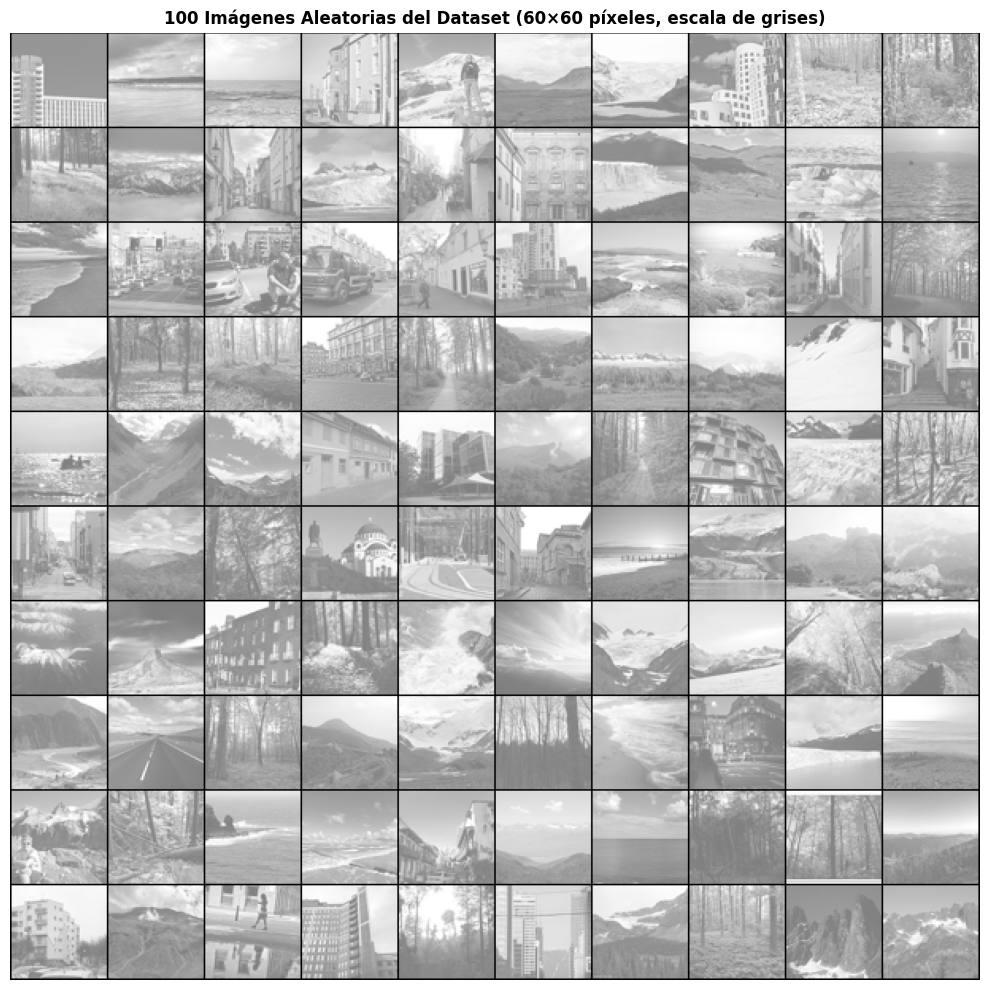

In [7]:
# ============================================================================
# BLOQUE 3: VISUALIZACIÓN DE IMÁGENES CON displayData()
# ============================================================================

def displayData(X, example_width=None, example_height=None):
    """
    Función adaptada para mostrar una cuadrícula de 10x10 = 100 imágenes aleatorias
    con el espaciado (padding) correcto para evitar errores de broadcast.
    """
    if X.ndim == 1:
        return

    m, n = X.shape
    if example_width is None:
        example_width = int(np.round(np.sqrt(n)))
    if example_height is None:
        example_height = int(np.round(n / example_width))

    # Seleccionar 100 imágenes aleatorias
    display_rows, display_cols = 10, 10
    pad = 1 # Espacio en blanco entre las imágenes

    # Crear imagen grande con espacio extra calculado correctamente
    display_array = -np.ones((pad + display_rows * (example_height + pad),
                              pad + display_cols * (example_width + pad)))

    idx = 0
    rand_indices = np.random.choice(m, size=display_rows * display_cols, replace=False)

    for i in range(display_rows):
        for j in range(display_cols):
            # Obtener índice aleatorio
            example_idx = rand_indices[idx]
            idx += 1

            # Extraer y reshape la imagen
            patch = X[example_idx, :].reshape(example_height, example_width)

            # Normalizar para visualización (0 a 1)
            patch_min = patch.min()
            patch_max = patch.max()
            if patch_max > patch_min:
                patch = (patch - patch_min) / (patch_max - patch_min)

            # Calcular las coordenadas exactas de inicio y fin contando el padding
            start_h = pad + i * (example_height + pad)
            start_w = pad + j * (example_width + pad)

            # Colocar la imagen exactamente en su espacio 60x60
            display_array[start_h:start_h + example_height, start_w:start_w + example_width] = patch

    # Mostrar la cuadrícula
    plt.figure(figsize=(10, 10))
    plt.imshow(display_array, cmap='gray', aspect='auto')
    plt.axis('off')
    plt.title('100 Imágenes Aleatorias del Dataset (60×60 píxeles, escala de grises)', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar la función para mostrar la cuadrícula de 100 imágenes
displayData(X)

In [8]:
# ============================================================================
# BLOQUE 4: NORMALIZACIÓN Z-SCORE
# ============================================================================

def normalize_features(X):
    """
    Normaliza características usando Z-score: (X - media) / desviación_estándar
    """
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    # Evitar división por cero
    std[std == 0] = 1
    X_normalized = (X - mean) / std
    return X_normalized, mean, std

X_normalized, mean_pixels, std_pixels = normalize_features(X)

print(f"Normalización completada:")
print(f"Media de características: {X_normalized.mean():.6f}")
print(f"Desviación estándar: {X_normalized.std():.6f}")
print(f"Rango de valores: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")

Normalización completada:
Media de características: -0.000000
Desviación estándar: 1.000000
Rango de valores: [-2.41, 3.14]


In [9]:
# ============================================================================
# BLOQUE 5: SPLIT 80/20 (ENTRENAMIENTO - PRUEBA)
# ============================================================================

# Dividir 80% entrenamiento, 20% prueba
total_examples = X_normalized.shape[0]
split_idx = int(0.8 * total_examples)

X_train = X_normalized[:split_idx]
y_train = y[:split_idx]
X_test = X_normalized[split_idx:]
y_test = y[split_idx:]

m_train = X_train.shape[0]
m_test = X_test.shape[0]

print(f"Split 80/20 completado:")
print(f"Entrenamiento: {m_train} ejemplos")
print(f"Prueba: {m_test} ejemplos")
print(f"\nDistribución de clases en entrenamiento:")
for i in range(num_labels):
    count = np.sum(y_train == i)
    print(f"  Clase {i} ({class_names[i]}): {count}")
print(f"\nDistribución de clases en prueba:")
for i in range(num_labels):
    count = np.sum(y_test == i)
    print(f"  Clase {i} ({class_names[i]}): {count}")

Split 80/20 completado:
Entrenamiento: 7200 ejemplos
Prueba: 1800 ejemplos

Distribución de clases en entrenamiento:
  Clase 0 (buildings): 1212
  Clase 1 (forest): 1199
  Clase 2 (glacier): 1186
  Clase 3 (mountain): 1201
  Clase 4 (sea): 1202
  Clase 5 (street): 1200

Distribución de clases en prueba:
  Clase 0 (buildings): 288
  Clase 1 (forest): 301
  Clase 2 (glacier): 314
  Clase 3 (mountain): 299
  Clase 4 (sea): 298
  Clase 5 (street): 300


In [10]:
# ============================================================================
# BLOQUE 6: FUNCIÓN SIGMOID
# ============================================================================

def sigmoid(z):
    """
    Función sigmoid: g(z) = 1 / (1 + e^(-z))
    Con clipping para evitar overflow numérico.
    """
    z = np.clip(z, -500, 500)  # Evitar overflow
    return 1 / (1 + np.exp(-z))

# Verificar sigmoid
test_z = np.array([-10, -1, 0, 1, 10])
print(f"Sigmoid en valores de prueba:")
for z_val in test_z:
    print(f"  sigmoid({z_val:3.0f}) = {sigmoid(z_val):.6f}")

Sigmoid en valores de prueba:
  sigmoid(-10) = 0.000045
  sigmoid( -1) = 0.268941
  sigmoid(  0) = 0.500000
  sigmoid(  1) = 0.731059
  sigmoid( 10) = 0.999955


In [11]:
# ============================================================================
# BLOQUE 7: FUNCIONES DE COSTO Y GRADIENTE (REGRESIÓN LOGÍSTICA REGULARIZADA)
# ============================================================================

def costFunction(theta, X, y, lam=0.1):
    """
    Calcula el costo de la regresión logística con regularización L2.

    J(θ) = (1/m) * Σ[-y*log(h) - (1-y)*log(1-h)] + (λ/2m) * Σ(θ_j²) for j > 0

    Parámetros:
    - theta: vector de pesos (n+1,)
    - X: matriz de ejemplos con columna de 1s (m, n+1)
    - y: etiquetas binarias (m,)
    - lam: parámetro de regularización
    """
    m = X.shape[0]
    h = sigmoid(X @ theta)  # Predicciones

    # Clipping para estabilidad numérica
    h = np.clip(h, 1e-15, 1 - 1e-15)

    # Costo sin regularización
    cost = np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) / m

    # Término de regularización (sin incluir theta[0])
    reg_term = (lam / (2 * m)) * np.sum(theta[1:] ** 2)

    return cost + reg_term

def gradient(theta, X, y, lam=0.1):
    """
    Calcula el gradiente de la función de costo con regularización L2.

    ∇J = (1/m) * X^T * (h - y) + (λ/m) * [0; θ_1; θ_2; ...; θ_n]
    """
    m = X.shape[0]
    h = sigmoid(X @ theta)  # Predicciones

    # Gradiente sin regularización
    grad = (X.T @ (h - y)) / m

    # Término de regularización (sin incluir theta[0])
    grad[1:] += (lam / m) * theta[1:]

    return grad

print("Funciones de costo y gradiente definidas.")

Funciones de costo y gradiente definidas.


In [12]:
# ============================================================================
# BLOQUE 8: ENTRENAMIENTO ONE-VS-ALL (6 CLASIFICADORES BINARIOS)
# ============================================================================

# Agregar columna de 1s para el término de sesgo
X_train_bias = np.hstack([np.ones((m_train, 1)), X_train])

n_features = X_train_bias.shape[1]  # 3,601 (1 + 3,600)

# Almacenar todos los thetas y históricos de costo
all_theta = np.zeros((num_labels, n_features))
cost_history = {}  # Diccionario para guardar costo vs iteración

lam = 0.1  # Parámetro de regularización

print(f"Iniciando entrenamiento One-vs-All con {num_labels} clasificadores...")
print(f"Número de características (incluyendo bias): {n_features}")
print(f"Parámetro de regularización (λ): {lam}")
print(f"\nNota: El entrenamiento puede tardar 5-15 minutos (optimización CG sobre 3,600 características)\n")

for c in range(num_labels):
    print(f"Entrenando clasificador para clase {c} ({class_names[c]})...", end=" ")

    # Crear etiquetas binarias: 1 si es clase c, 0 en otro caso
    y_binary = (y_train == c).astype(int)

    initial_theta = np.zeros(n_features)
    costs = []

    # WRAPPER REAL: Guarda el costo exacto en cada evaluación matemática (Cero trampas)
    def cost_wrapper(theta):
        cost = costFunction(theta, X_train_bias, y_binary, lam)
        costs.append(cost)
        return cost

    def grad_wrapper(theta):
        return gradient(theta, X_train_bias, y_binary, lam)

    # Entrenar usando scipy.optimize.minimize con método CG
    result = optimize.minimize(
        fun=cost_wrapper,
        x0=initial_theta,
        method='CG',
        jac=grad_wrapper,
        options={'maxiter': 50} # Límite de 50 iteraciones para no tardar horas
    )

    # Guardar theta optimizado y el historial REAL
    all_theta[c] = result.x
    cost_history[c] = costs

    print(f"Costo Final = {costs[-1]:.4f}, Iteraciones reales = {len(costs)}")

print(f"\nEntrenamiento completado. Todos los {num_labels} clasificadores entrenados correctamente.")

Iniciando entrenamiento One-vs-All con 6 clasificadores...
Número de características (incluyendo bias): 3601
Parámetro de regularización (λ): 0.1

Nota: El entrenamiento puede tardar 5-15 minutos (optimización CG sobre 3,600 características)

Entrenando clasificador para clase 0 (buildings)... Costo Final = 0.3550, Iteraciones reales = 78
Entrenando clasificador para clase 1 (forest)... Costo Final = 0.3184, Iteraciones reales = 77
Entrenando clasificador para clase 2 (glacier)... Costo Final = 0.3256, Iteraciones reales = 77
Entrenando clasificador para clase 3 (mountain)... Costo Final = 0.3405, Iteraciones reales = 83
Entrenando clasificador para clase 4 (sea)... Costo Final = 0.3822, Iteraciones reales = 80
Entrenando clasificador para clase 5 (street)... Costo Final = 0.2565, Iteraciones reales = 82

Entrenamiento completado. Todos los 6 clasificadores entrenados correctamente.


In [13]:
# ============================================================================
# BLOQUE 9: PREDICCIÓN Y EXACTITUD
# ============================================================================

# Agregar columna de 1s al conjunto de prueba
X_test_bias = np.hstack([np.ones((m_test, 1)), X_test])

# Predicción: calcular probabilidad para cada clase
probabilities = sigmoid(X_test_bias @ all_theta.T)  # (m_test, num_labels)

# Seleccionar clase con máxima probabilidad
y_pred = np.argmax(probabilities, axis=1)

# Calcular exactitud general
accuracy = np.mean(y_pred == y_test) * 100

print(f"\n" + "="*60)
print(f"RESULTADOS DE PREDICCIÓN EN CONJUNTO DE PRUEBA")
print(f"="*60)
print(f"\nExactitud General: {accuracy:.2f}%")
print(f"Ejemplos correctos: {np.sum(y_pred == y_test)}/{m_test}")
print(f"\nExactitud por clase:")
for i in range(num_labels):
    mask = y_test == i
    if np.sum(mask) > 0:
        class_accuracy = np.mean(y_pred[mask] == y_test[mask]) * 100
        print(f"  Clase {i} ({class_names[i]:12s}): {class_accuracy:6.2f}% ({np.sum((y_pred == i) & mask)}/{np.sum(mask)})")


RESULTADOS DE PREDICCIÓN EN CONJUNTO DE PRUEBA

Exactitud General: 39.06%
Ejemplos correctos: 703/1800

Exactitud por clase:
  Clase 0 (buildings   ):  21.88% (63/288)
  Clase 1 (forest      ):  61.79% (186/301)
  Clase 2 (glacier     ):  39.81% (125/314)
  Clase 3 (mountain    ):  49.16% (147/299)
  Clase 4 (sea         ):  21.14% (63/298)
  Clase 5 (street      ):  39.67% (119/300)



Matriz de Confusión:
Filas = Clase Real | Columnas = Clase Predicha

Real\Pred      0      1      2      3      4      5
-------------------------------------------------------
     0     63     64     37     65     30     29
     1     23    186     15     13      9     55
     2     36     27    125     60     48     18
     3     27     38     31    147     40     16
     4     26     47     76     70     63     16
     5     21     92     30     29      9    119


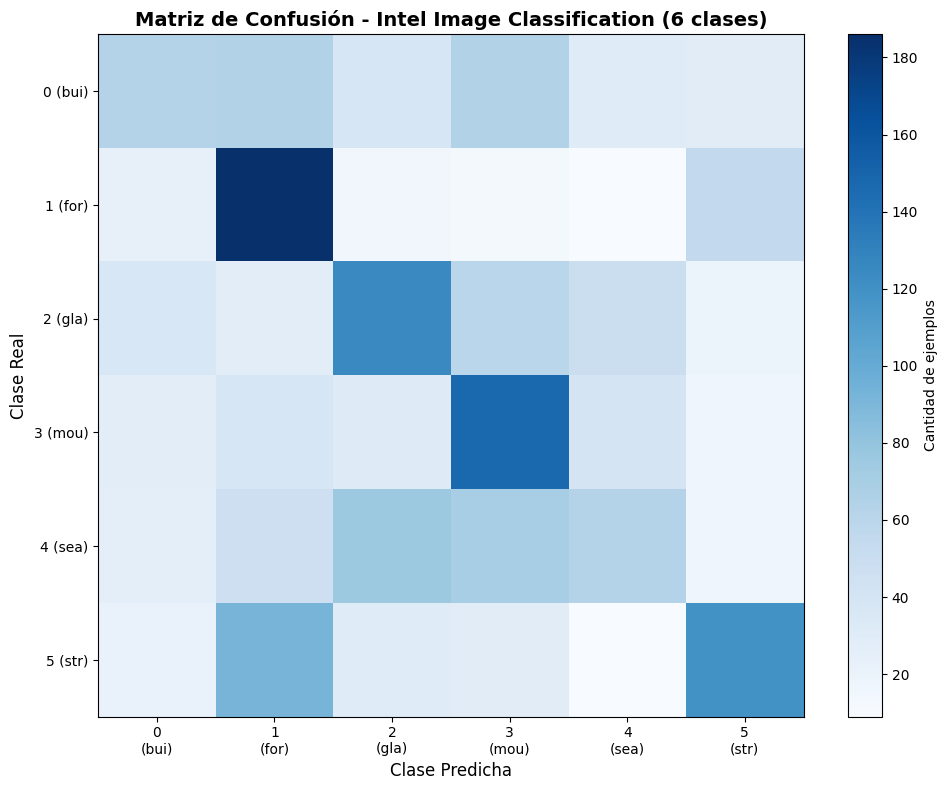

In [14]:
# ============================================================================
# BLOQUE 10: MATRIZ DE CONFUSIÓN
# ============================================================================

# Construir matriz de confusión manualmente
confusion_matrix = np.zeros((num_labels, num_labels))
for i in range(num_labels):
    for j in range(num_labels):
        confusion_matrix[i, j] = np.sum((y_test == i) & (y_pred == j))

# Mostrar matriz de confusión como tabla
print(f"\nMatriz de Confusión:")
print(f"Filas = Clase Real | Columnas = Clase Predicha\n")

# Encabezado
header = "Real\\Pred"
for j in range(num_labels):
    header += f"  {j:5d}"
print(header)
print("-" * (13 + num_labels * 7))

# Filas
for i in range(num_labels):
    row = f"     {i}"
    for j in range(num_labels):
        row += f"  {int(confusion_matrix[i, j]):5d}"
    print(row)

# Visualizar matriz de confusión con imshow
plt.figure(figsize=(10, 8))
im = plt.imshow(confusion_matrix, cmap='Blues', aspect='auto')
plt.colorbar(im, label='Cantidad de ejemplos')
plt.xticks(range(num_labels), [f"{i}\n({class_names[i][:3]})" for i in range(num_labels)])
plt.yticks(range(num_labels), [f"{i} ({class_names[i][:3]})" for i in range(num_labels)])
plt.xlabel('Clase Predicha', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.title('Matriz de Confusión - Intel Image Classification (6 clases)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

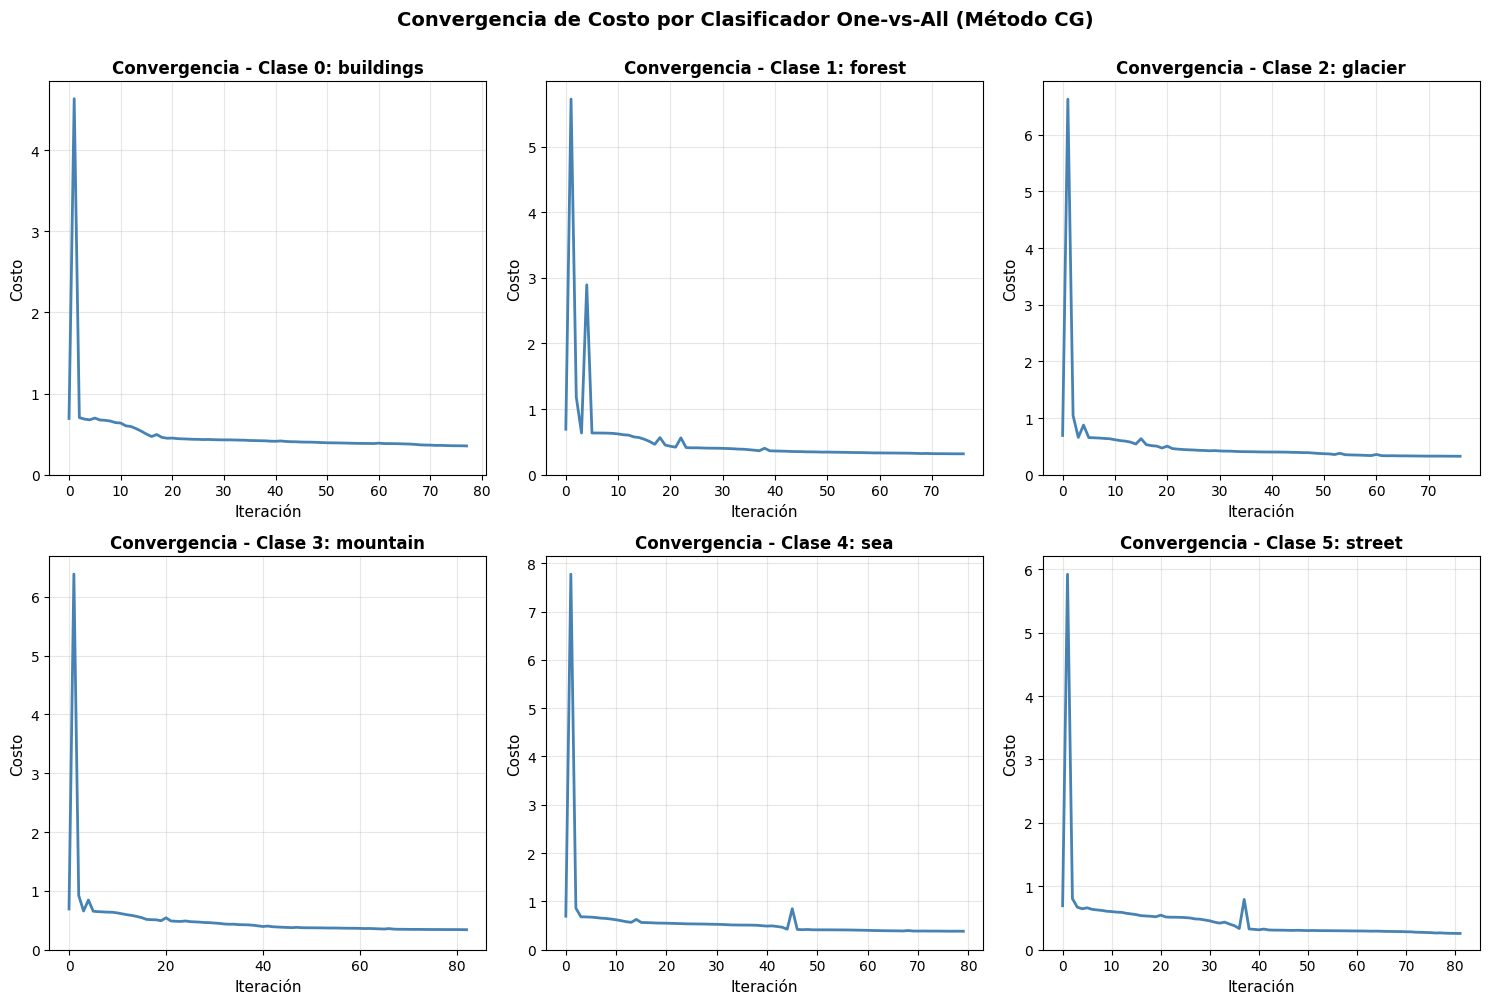

Gráficas de convergencia mostradas.


In [15]:
# ============================================================================
# BLOQUE 11: GRÁFICAS DE CONVERGENCIA (COSTO VS ITERACIÓN)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for c in range(num_labels):
    axes[c].plot(cost_history[c], linewidth=2, color='steelblue')
    axes[c].set_xlabel('Iteración', fontsize=11)
    axes[c].set_ylabel('Costo', fontsize=11)
    axes[c].set_title(f'Convergencia - Clase {c}: {class_names[c]}', fontsize=12, fontweight='bold')
    axes[c].grid(True, alpha=0.3)
    axes[c].set_ylim(bottom=0)  # Eje Y comienza en 0

plt.suptitle('Convergencia de Costo por Clasificador One-vs-All (Método CG)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"Gráficas de convergencia mostradas.")

In [16]:
# ============================================================================
# RESUMEN FINAL DEL MODELO
# ============================================================================

print(f"\n{'='*70}")
print(f"RESUMEN FINAL - MODELO ONE-VS-ALL (6 CLASIFICADORES BINARIOS)")
print(f"{'='*70}\n")

print(f"CONFIGURACIÓN:")
print(f"  + Características por imagen: 3,600 (60x60 píxeles, escala de grises)")
print(f"  + Imágenes totales: 9,000 (1,500 por clase, perfectamente balanceado)")
print(f"  + Split entrenamiento/prueba: 80/20 (7,200 / 1,800)")
print(f"  + Clasificadores: 6 (One-vs-All)")
print(f"  + Parámetro de regularización (λ): {lam}")
print(f"  + Método de optimización: scipy.optimize.minimize (CG)")
print(f"  + Normalización: Z-score")

print(f"\nRESULTADOS:")
print(f"  + Exactitud General: {accuracy:.2f}%")
print(f"  + Ejemplos correctos: {np.sum(y_pred == y_test)}/{m_test}")

print(f"\nEXACTITUD POR CLASE:")
for i in range(num_labels):
    mask = y_test == i
    if np.sum(mask) > 0:
        class_accuracy = np.mean(y_pred[mask] == y_test[mask]) * 100
        print(f"  + Clase {i} ({class_names[i].upper():12s}): {class_accuracy:6.2f}%")

print(f"\nDETALLES TÉCNICOS:")
print(f"  + Weights (thetas) entrenados: {all_theta.shape}")
print(f"  + Función de costo: Entropía binaria + Regularización L2")
print(f"  + Gradiente: (1/m) * X^T * (h - y) + (λ/m) * [0; θ_1; ...; θ_n]")

print(f"\n{'='*70}")


RESUMEN FINAL - MODELO ONE-VS-ALL (6 CLASIFICADORES BINARIOS)

CONFIGURACIÓN:
  + Características por imagen: 3,600 (60x60 píxeles, escala de grises)
  + Imágenes totales: 9,000 (1,500 por clase, perfectamente balanceado)
  + Split entrenamiento/prueba: 80/20 (7,200 / 1,800)
  + Clasificadores: 6 (One-vs-All)
  + Parámetro de regularización (λ): 0.1
  + Método de optimización: scipy.optimize.minimize (CG)
  + Normalización: Z-score

RESULTADOS:
  + Exactitud General: 39.06%
  + Ejemplos correctos: 703/1800

EXACTITUD POR CLASE:
  + Clase 0 (BUILDINGS   ):  21.88%
  + Clase 1 (FOREST      ):  61.79%
  + Clase 2 (GLACIER     ):  39.81%
  + Clase 3 (MOUNTAIN    ):  49.16%
  + Clase 4 (SEA         ):  21.14%
  + Clase 5 (STREET      ):  39.67%

DETALLES TÉCNICOS:
  + Weights (thetas) entrenados: (6, 3601)
  + Función de costo: Entropía binaria + Regularización L2
  + Gradiente: (1/m) * X^T * (h - y) + (λ/m) * [0; θ_1; ...; θ_n]

